# Conjugate-Computational Variational Message Passing (CVI)

In [ ]:
using RxInfer, Random, LinearAlgebra, Plots, StableRNGs, ExponentialFamilyProjection
using Manopt: ConstantLength
include("call_closed_prod.jl")

In this notebook, the usage of Conjugate-Computational Variational Inference (CVI) will be described. The implementation of CVI follows the paper [Probabilistic programming with stochastic variational message passing](https://reader.elsevier.com/reader/sd/pii/S0888613X22000950?token=EFB22E01793BD0BF73EECC9702C315644969403BD44B13FA850E9F66C8A49E88C0D5C68A9AD03301C609DA443DB33F80&originRegion=eu-west-1&originCreation=20221027115856). RxInfer runs it with `CVIProjection`, an approximation method of the Delta node: it samples the inputs of a nonlinear function, pushes the samples through the function and projects the result onto an exponential family with [ExponentialFamilyProjection.jl](https://github.com/ReactiveBayes/ExponentialFamilyProjection.jl).

This notebook will first describe an example in which CVI is used, and then the requirements it places on a model.

## An example: nonlinear dynamical system

A group of researchers is performing a tracking experiment on some moving object along a 1-dimensional trajectory. The object is moving at a constant velocity, meaning that its position increases constantly over time. However, the researchers do not have access to the absolute position $z_t$ at time $t$. Instead they have access to the observed squared distance $y_t$ between the object and some reference point $s$. Because of budget cuts, the servo moving the object and the measurement devices are quite outdated and therefore lead to noisy measurements:

In [2]:
# data generating process
nr_observations = 50
reference_point = 53
hidden_location = collect(1:nr_observations) + rand(StableRNG(124), NormalMeanVariance(0.0, sqrt(5)), nr_observations)
measurements = (hidden_location .- reference_point).^2 + rand(MersenneTwister(124), NormalMeanVariance(0.0, 5), nr_observations);

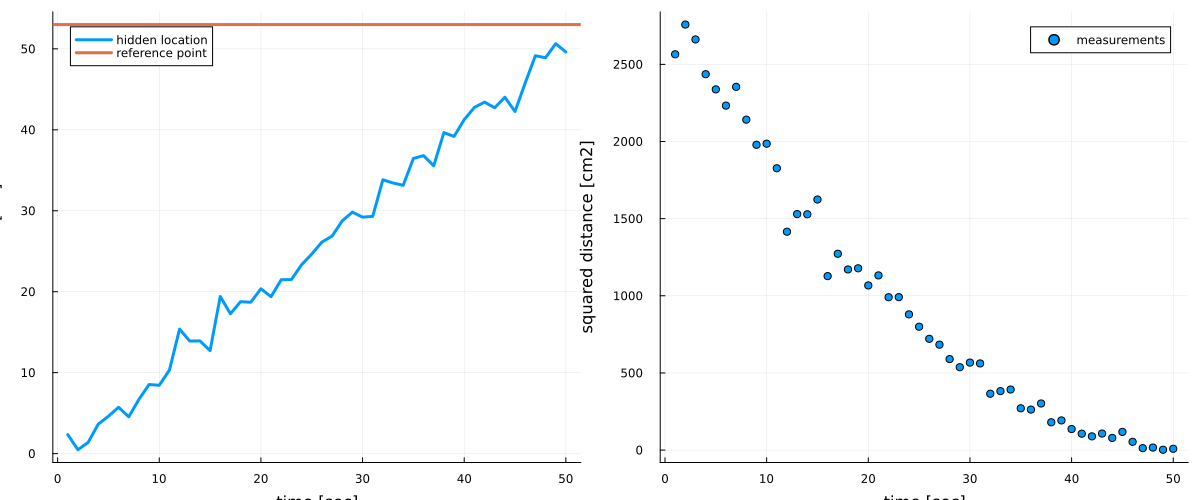

In [3]:
# plot hidden location and reference frame
p1 = plot(1:nr_observations, hidden_location, linewidth=3, legend=:topleft, label="hidden location")
hline!([reference_point], linewidth=3, label="reference point")
xlabel!("time [sec]"), ylabel!("location [cm]")

# plot measurements
p2 = scatter(1:nr_observations, measurements, linewidth=3, label="measurements")
xlabel!("time [sec]"), ylabel!("squared distance [cm2]")

plot(p1, p2, size=(1200, 500))

The researchers are interested in quantifying this noise and in tracking the unobserved location of the object. As a result of this uncertainty, the researchers employ a probabilistic modeling approach. They formulate the probabilistic model

$$\begin{aligned}
 p(\tau) & = \Gamma(\tau \mid \alpha_{\tau}, \beta_{\tau}),\\
 p(\gamma) & = \Gamma(\gamma \mid \alpha_{\gamma}, \beta_{\gamma}),\\
 p(z_t \mid z_{t - 1}, \tau) & = \mathcal{N}(z_t \mid z_{t - 1} + 1, \tau^{-1}),\\
 p(y_t \mid z_t, \gamma) & = \mathcal{N}(y_t \mid (z_t - s)^2, \gamma^{-1}),
\end{aligned}$$
where the researchers put priors on the process and measurement noise parameters, $\tau$ and $\gamma$, respectively. They do this, because they do not know the accuracy of their devices.

The researchers have recently heard of this cool probabilistic programming package `RxInfer.jl`. They decided to give it a try and create the above model as follows:

In [4]:
function compute_squared_distance(z)
    (z - reference_point)^2
end;

In [ ]:
@model function measurement_model(y)

    # set priors on precision parameters
    τ ~ Gamma(shape = 0.01, rate = 0.01)
    γ ~ Gamma(shape = 0.01, rate = 0.01)
    
    # specify estimate of initial location
    z[1] ~ Normal(mean = 0, precision = τ)
    μ[1] := compute_squared_distance(z[1])
    y[1] ~ Normal(mean = μ[1], precision = γ)

    # loop over observations
    for t in 2:length(y)

        # specify state transition model
        z[t] ~ Normal(mean = z[t-1] + 1, precision = τ)

        # specify non-linear observation model
        μ[t] := compute_squared_distance(z[t])
        y[t] ~ Normal(mean = μ[t], precision = γ)
        
    end

end

But here is the problem, our `compute_squared_distance` function is already compelx enough such that the exact Bayesian inference is intractable in this model. But the researchers knew that the `RxInfer.jl` supports a various collection of approximation methods for exactly such cases. One of these approximations is called CVI. CVI allows us to perform probabilistic inference around the non-linear measurement function. In general, for any (non-)linear relationship `y = f(x1, x2, ..., xN)` CVI can be employed, by specifying the function `f` and by adding this relationship inside the `@model` macro as `y ~ f(x1, x2, ...,xN)`. The `@model` macro will generate a factor node with node function `p(y | x1, x2, ..., xN) = δ(y - f(x1, x2, ...,xN))`.

The use of this non-linearity requires us to specify that we would like to use CVI. This can be done by specifying the node's algorithm with the `@algorithm` macro as:

In [ ]:
projection_parameters = ProjectionParameters(stepsize = ConstantLength(1.0))

@algorithm function measurement_algorithm()
    compute_squared_distance() -> CVIProjection(in_prjparams = (in_1 = projection_parameters,), out_prjparams = projection_parameters)
end;

In general, for any (non-)linear function `f()`, CVI can be enabled with the `@algorithm` macro as:

```julia
@algorithm function model_algorithm(...)
    f() -> CVIProjection(args...)
end
```

See `?CVIProjection` for more information about the `args...`. Each projection is a gradient descent over the parameters of the exponential family, and `ProjectionParameters` from ExponentialFamilyProjection.jl sets how it runs. With the default step length, `ConstantLength(0.1)`, its 100 iterations do not travel far enough for this model, whose locations go up to 50, so here the steps have length 1. `CVIProjection` draws its samples from the random number generator of the inference, which is seeded below with the `context` option.

In our model, the `z` variables are connected to the non-linear node function. So in order to run probabilstic inference with `CVI` we need to enforce a constraint on the joint posterior distribution. Specifically, we need to create a factorization in which the variables that are directly connected to non-linearities are assumed to be independent from the rest of the variables.

In the above example, we will assume the following posterior factorization:

In [ ]:
@constraints function measurement_constraints()
    q(z, μ, τ, γ) = q(z, μ)q(τ)q(γ)
    μ(z) :: CallClosedProd()
    q(z) :: CallClosedProd()
end;

The factorization can be explained by the set of two constraints, one for getting CVI to run, and one for assuming a mean-field factorization around the normal node as 
```julia
@constraints function posterior_constraints()
    q(z, γ) = q(z)q(γ) # CVI
    q(z, τ) = q(z)q(τ) # the mean-field assumption around normal node
end
```

The two form constraints concern what `CVIProjection` sends back to `z`: its message is the projected marginal of `z` divided by the message that arrived from `z`, and it is left unevaluated. `CallClosedProd`, defined in `call_closed_prod.jl` next to this notebook, resolves the product of that division with the Gaussian messages on the other edges of `z` into one Gaussian, for the marginal `q(z)` and for the messages `μ(z)` that `z` sends on.

Because the engineers are using `RxInfer.jl`, they can automate the inference procedure. They track the inference performance using the Bethe free energy.

In [ ]:
initialization = @initialization begin
    μ(z) = NormalMeanVariance(0, 5)
    μ(μ) = NormalMeanVariance(0, 5)
    q(z) = NormalMeanVariance(0, 5)
    q(μ) = NormalMeanVariance(0, 5)
    q(τ) = GammaShapeRate(1, 1)
    q(γ) = GammaShapeRate(1, 1)
end

results = infer(
    model = measurement_model(),
    data = (y = measurements,),
    iterations = 50,
    free_energy = true,
    returnvars = (z = KeepLast(),),
    constraints = measurement_constraints(),
    algorithm = measurement_algorithm(),
    initialization = initialization,
    options = (context = (rng = StableRNG(42),),),
)

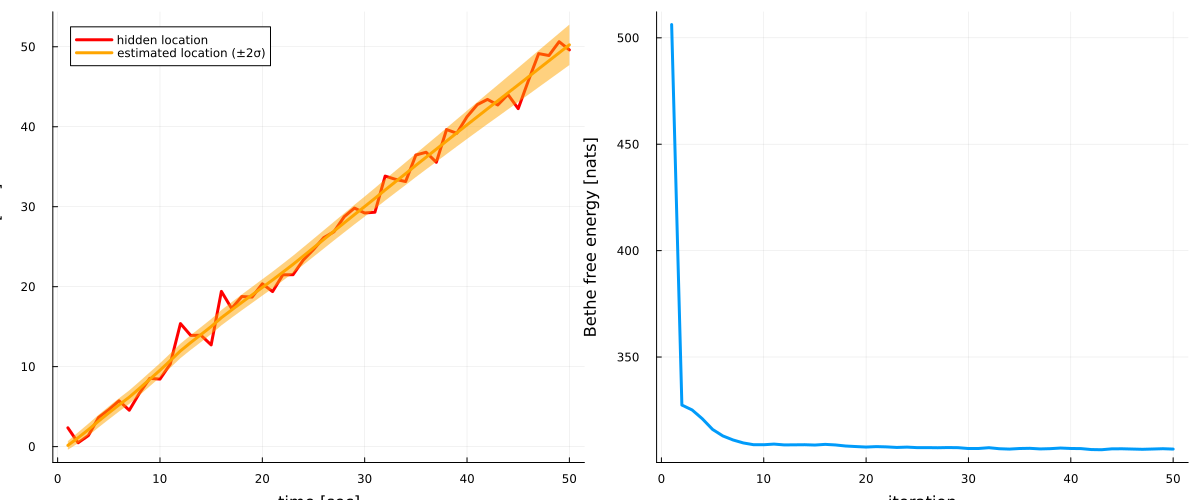

In [9]:
# plot estimates for location
p1 = plot(collect(1:nr_observations), hidden_location, label = "hidden location", legend=:topleft, linewidth=3, color = :red)
plot!(map(mean, results.posteriors[:z]), label = "estimated location (±2σ)", ribbon = map(x -> 2*std(x), results.posteriors[:z]), fillalpha=0.5, linewidth=3, color = :orange)
xlabel!("time [sec]"), ylabel!("location [cm]")

# plot Bethe free energy
p2 = plot(results.free_energy, linewidth=3, label = "")
xlabel!("iteration"), ylabel!("Bethe free energy [nats]")

plot(p1, p2, size = (1200, 500))

## Requirements

There are several main requirements for the `CVIProjection` procedure to satisfy:
1. The `out` interface of the non-linearity must be independently factorized with respect to other variables in the model.
2. The messages on input interfaces (`x1, x2, ..., xN`) are required to be from the exponential family of distributions.
3. Where a variable on an input interface has more edges than the non-linearity and one other node, its marginal and its messages need a form constraint that resolves the unevaluated division, as `CallClosedProd` does above.

In `RxInfer`, you can satisfy the first requirement by using appropriate factor nodes (`Normal`, `Gamma`, `Bernoulli`, etc) and the second and third by specifying the `@constraints` macro. In general you can specify this procedure as

```julia
@model function model(...)
    ...
    y ~ f(x1, x2, ..., xN)
    ... ~ Node2(z1,..., y, zM) # some node that is using the out interface of the non-linearity
    ... 
end

@constraints function model_constraints()
    q(y, z1, ..., zM) = q(y)q(z1,...,zM)
    ...
end

@algorithm function model_algorithm(...)
    f() -> CVIProjection(args...)
end
```

Note that not all exponential family distributions are implemented.